In [ ]:
import pandas as pd

In [92]:
# 1) CSV 불러오기
df = pd.read_csv("data.csv", encoding="utf-8-sig")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   행정구역별(시군구)      570 non-null    object
 1   성별              570 non-null    object
 2   연령별             570 non-null    object
 3   시점              570 non-null    int64 
 4   일반가구원           570 non-null    int64 
 5   가구주             570 non-null    int64 
 6   가구주의 배우자        570 non-null    object
 7   자녀              570 non-null    object
 8   자녀의 배우자         570 non-null    object
 9   가구주의 부모         570 non-null    object
 10  배우자의 부모         570 non-null    object
 11  손자녀 그 배우자       570 non-null    object
 12  친손자녀·그 배우자      570 non-null    object
 13  외손자녀·그 배우자      570 non-null    object
 14  증손자녀·그 배우자      570 non-null    object
 15  조부모             570 non-null    object
 16  형제자매·그 배우자      570 non-null    int64 
 17  형제자매의 자녀·그 배우자  570 non-null    object
 18  부모의 형제자매·그

In [93]:
df.head()

,행정구역별(시군구),성별,연령별,시점,일반가구원,가구주,가구주의 배우자,자녀,자녀의 배우자,가구주의 부모,...,손자녀 그 배우자,친손자녀·그 배우자,외손자녀·그 배우자,증손자녀·그 배우자,조부모,형제자매·그 배우자,형제자매의 자녀·그 배우자,부모의 형제자매·그 배우자,기타 친·인척,기타 동거인
0,전국,계,합계,2015,48339559,19111030,10440050,15029782,234046,1281004,...,-,440087,172851,3325,41864,758543,154183,22103,52911,353609
1,전국,계,합계,2016,48551348,19367696,10503992,14928884,231261,1270659,...,-,413095,174495,3188,40316,739950,151575,22205,51379,408291
2,전국,계,합계,2017,48614907,19673875,10534559,14675520,215251,1246177,...,-,388105,176291,3042,40364,740091,152888,23052,55443,453429
3,전국,계,합계,2018,48664922,19979188,10555209,14413659,197312,1245526,...,-,357879,174071,2756,40744,741466,153814,24326,55129,496762
4,전국,계,합계,2019,48674177,20343188,10571041,14071845,182245,1229037,...,-,332694,172304,2607,40041,736103,152723,24910,57531,540003


In [ ]:
# 2) 필요한 컬럼만 남기기 + 2015년 이후 데이터만
df = df[df['시점'] >= 2015][['시점', '성별', '연령별', '일반가구원']]

# 3) 불필요한 집계행 제거 (성별=계, 연령별=합계), 성별이 '남자' 또는 '여자'인 행만 선택,연령별이 '합계'가 아닌 행만 선택
df = df[(df['성별'].isin(['남자', '여자'])) & (df['연령별'] != '합계')]
# 원본 df 인덱스 리셋

# 3) 불필요한 집계행 제거
#   - 성별: '계' 제거
#   - 연령별: '합계', '15~64세', '65세이상' 제거 (단, '15세미만'은 유지)
exclude_age = ['합계', '15~64세', '65세이상']
df = df[(df['성별'].isin(['남자','여자'])) & (~df['연령별'].isin(exclude_age))]

df = df.reset_index(drop=True)

In [95]:
df.head()

,시점,성별,연령별,일반가구원
0,2015,남자,15세미만,3556446
1,2016,남자,15세미만,3481573
2,2017,남자,15세미만,3405509
3,2018,남자,15세미만,3326313
4,2019,남자,15세미만,3236713


In [96]:


# 4) 연도별 성별 일반가구원 합계
gender_year = df.groupby(['시점', '성별'])['일반가구원'].sum().unstack()

# 5) 연도별 연령대별 일반가구원 합계
age_year = df.groupby(['시점', '연령별'])['일반가구원'].sum().unstack()

# 결과 확인
print("=== 연도별 남/여 일반가구원 ===")
print(gender_year.head())

print("\n=== 연도별 연령대별 일반가구원 ===")
print(age_year.head())

=== 연도별 남/여 일반가구원 ===
성별          남자        여자
시점                      
2015  23804846  24534713
2016  23918710  24632638
2017  23973333  24641574
2018  24010719  24654203
2019  24029501  24644676

=== 연도별 연령대별 일반가구원 ===
연령별    15~19세    15세미만   20~24세   25~29세   30~34세   35~39세   40~44세   45~49세  \
시점                                                                             
2015  2835413  6888615  2763722  2972437  3570246  3765009  4194519  4242619   
2016  2715405  6753076  2796573  3020163  3394882  3841035  4016679  4350652   
2017  2573204  6613883  2750740  3109124  3210358  3898665  3904060  4386047   
2018  2410324  6465942  2722228  3204366  3076625  3912833  3766795  4346252   
2019  2262120  6296648  2676127  3284719  3023482  3789676  3698794  4289786   

연령별    50~54세   55~59세   60~64세   65~69세   70~74세   75~79세   80~84세   85세이상  
시점                                                                           
2015  4119181  3837143  2741704  2103674  1742546  1327847   7

In [97]:
# 2015년 이후 전체 기간 합계 (엑셀에서 합계 행처럼)
age_total = df.groupby('연령별')['일반가구원'].sum().sort_values(ascending=False)

print("=== 2015년 이후 연령별 합계 ===")
print(age_total)

=== 2015년 이후 연령별 합계 ===
연령별
15세미만     61781051
50~54세    41883577
45~49세    41144999
55~59세    40492625
40~44세    38750686
60~64세    35888914
35~39세    35613559
30~34세    32229205
25~29세    32146719
65~69세    26693600
20~24세    26073523
15~19세    23224969
70~74세    19556938
75~79세    15257900
80~84세    10252823
85세이상      6484463
Name: 일반가구원, dtype: int64


In [100]:
df.loc[df['연령별범주']=='15세미만','일반가구원'] //= 3
age_total_male_female = (
    df.groupby(['연령별', '성별'])['일반가구원']
      .sum()
      .reset_index()
      .sort_values(by='연령별', ascending=True)
)
print(age_total_male_female)

       연령별  성별     일반가구원
0   15~19세  남자  11846499
1   15~19세  여자  11378470
2    15세미만  남자  10589521
3    15세미만  여자  10004158
4   20~24세  남자  12297013
5   20~24세  여자  13776510
6   25~29세  남자  16678412
7   25~29세  여자  15468307
8   30~34세  남자  16574157
9   30~34세  여자  15655048
10  35~39세  남자  18118992
11  35~39세  여자  17494567
12  40~44세  남자  19609580
13  40~44세  여자  19141106
15  45~49세  여자  20442847
14  45~49세  남자  20702152
16  50~54세  남자  20982458
17  50~54세  여자  20901119
18  55~59세  남자  20142059
19  55~59세  여자  20350566
20  60~64세  남자  17609325
21  60~64세  여자  18279589
23  65~69세  여자  13858039
22  65~69세  남자  12835561
24  70~74세  남자   9052577
25  70~74세  여자  10504361
26  75~79세  남자   6560691
27  75~79세  여자   8697209
28  80~84세  남자   3908186
29  80~84세  여자   6344637
30   85세이상  남자   1957272
31   85세이상  여자   4527191


In [102]:
age_order = [
    '15세미만','15~19세','20~24세','25~29세','30~34세','35~39세',
    '40~44세','45~49세','50~54세','55~59세','60~64세',
    '65~69세','70~74세','75~79세','80~84세','85세이상'
]

df['연령별범주'] = pd.Categorical(df['연령별'], categories=age_order, ordered=True)

#df.loc[df['연령별범주']=='15세미만','일반가구원'] //= 3
age_total_male_female = (
    df.groupby(['연령별범주','성별'])['일반가구원']
      .sum()
      .reset_index()
      .sort_values(by=['연령별범주','성별'])
)

print(age_total_male_female)

     연령별범주  성별     일반가구원
0    15세미만  남자  10589521
1    15세미만  여자  10004158
2   15~19세  남자  11846499
3   15~19세  여자  11378470
4   20~24세  남자  12297013
5   20~24세  여자  13776510
6   25~29세  남자  16678412
7   25~29세  여자  15468307
8   30~34세  남자  16574157
9   30~34세  여자  15655048
10  35~39세  남자  18118992
11  35~39세  여자  17494567
12  40~44세  남자  19609580
13  40~44세  여자  19141106
14  45~49세  남자  20702152
15  45~49세  여자  20442847
16  50~54세  남자  20982458
17  50~54세  여자  20901119
18  55~59세  남자  20142059
19  55~59세  여자  20350566
20  60~64세  남자  17609325
21  60~64세  여자  18279589
22  65~69세  남자  12835561
23  65~69세  여자  13858039
24  70~74세  남자   9052577
25  70~74세  여자  10504361
26  75~79세  남자   6560691
27  75~79세  여자   8697209
28  80~84세  남자   3908186
29  80~84세  여자   6344637
30   85세이상  남자   1957272
31   85세이상  여자   4527191


C:\Users\4cat1\AppData\Local\Temp\ipykernel_18784\2161266966.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['연령별범주','성별'])['일반가구원']


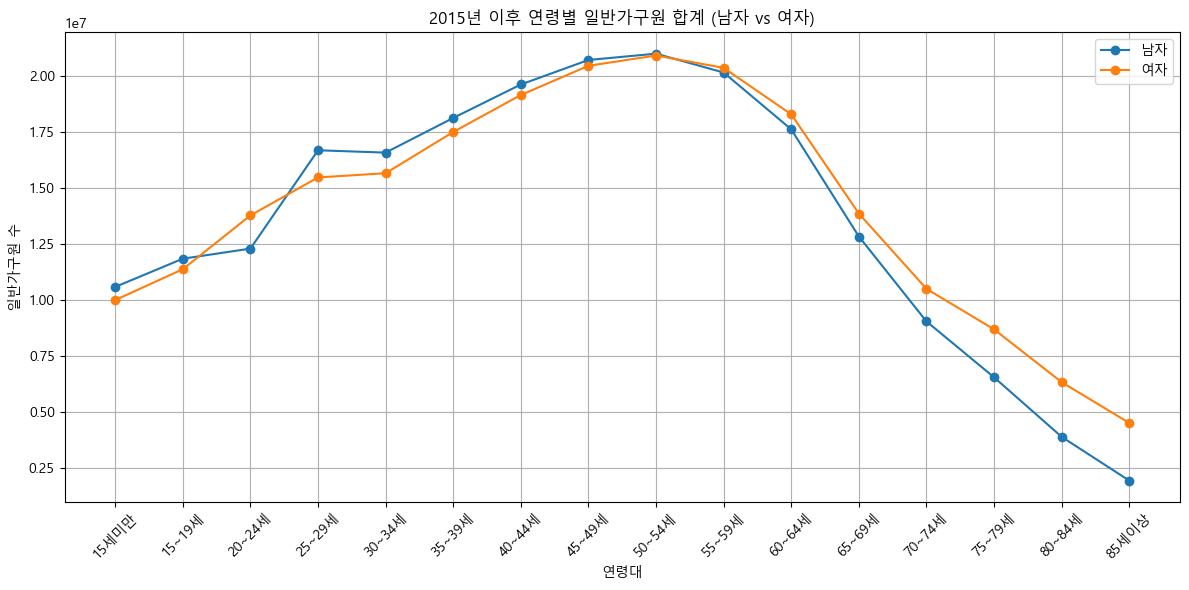

In [103]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.figure(figsize=(12,6))

# 남자
male = age_total_male_female[age_total_male_female['성별']=='남자']
plt.plot(male['연령별범주'], male['일반가구원'], marker='o', label='남자')

# 여자
female = age_total_male_female[age_total_male_female['성별']=='여자']
plt.plot(female['연령별범주'], female['일반가구원'], marker='o', label='여자')

plt.title("2015년 이후 연령별 일반가구원 합계 (남자 vs 여자)")
plt.xlabel("연령대")
plt.ylabel("일반가구원 수")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


✅ 결론
groupby 결과(agg)는 데이터 요약(long format)

pivot 결과(pivot_df)는 분석·시각화용(wide format)

즉, pivot은 “엑셀에서 피벗테이블 만드는 것과 같은 이유”로 쓰는 거예요. 데이터를 구조화해서, 연도별·연령별·성별을 한눈에 비교하거나 그래프를 쉽게 그리기 위해서죠.

In [104]:
pivot_df = df.pivot_table(
    index='시점', columns=['연령별범주','성별'], values='일반가구원', aggfunc='sum'
)

C:\Users\4cat1\AppData\Local\Temp\ipykernel_18784\3896958115.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = df.pivot_table(


C:\Users\4cat1\AppData\Local\Temp\ipykernel_18784\1386168812.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


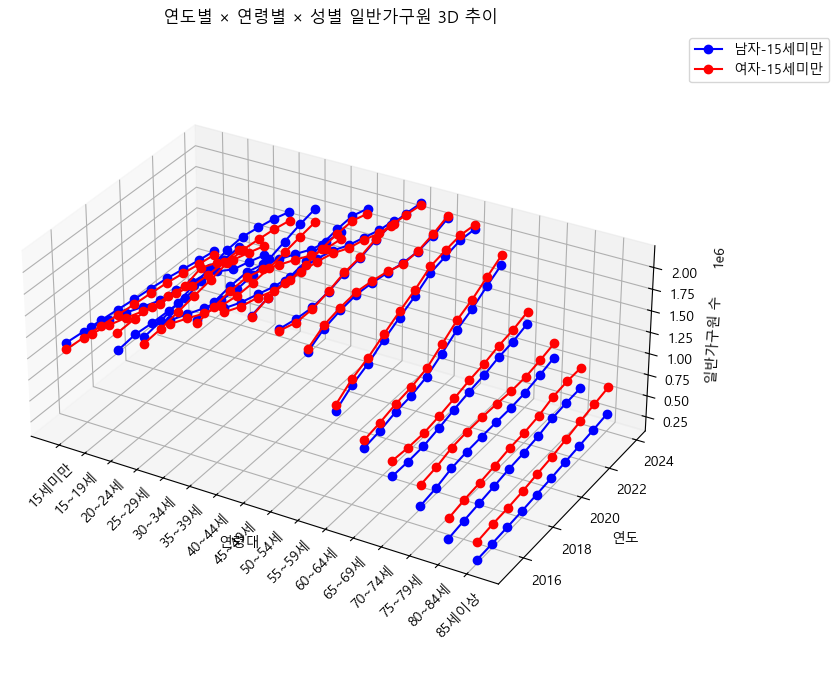

In [105]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(14,8))
ax = fig.add_subplot(111, projection='3d')
# 축 비율 조정 (x축:연령, y축:연도, z축:값)
ax.set_box_aspect([5,3,2])   # x축을 2배 길게
years = pivot_df.index.values
ages = pivot_df.columns.levels[0]
sexes = pivot_df.columns.levels[1]
#plt.subplots_adjust(left=0.2, right=0.8)  # 좌우 여백 조정

# 색상 팔레트
colors = {'남자':'blue','여자':'red'}

for s in sexes:
    for i, age in enumerate(ages):
        z_vals = pivot_df[(age, s)].values
        xs = np.full_like(years, i, dtype=float)  # 연령대 index
        ys = years
        ax.plot(xs, ys, z_vals, marker='o', color=colors[s], label=f"{s}-{age}" if i==0 else "")

ax.set_xticks(range(len(ages)))
ax.set_xticklabels(ages, rotation=45)
ax.set_xlabel("연령대")
ax.set_ylabel("연도")
ax.set_zlabel("일반가구원 수")
ax.set_title("연도별 × 연령별 × 성별 일반가구원 3D 추이")
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
ax.set_position([0.2, 0.1, 0.6, 0.8])  
plt.show()


좋습니다. 지금까지 집계한 **연령별·성별 인구 데이터**를 토대로, “2015년 이후 인구 변화 트렌드”를 정리한 리포트를 작성해 드릴게요.  

---

# 📊 인구 변화 트렌드 리포트 (2015년 이후)

## 1. 전체 인구 구조 개요
- **15세 미만** 인구가 가장 큰 비중을 차지하며, 여전히 전체 인구 구조에서 중요한 축을 형성.  
- **중년층(40~59세)** 구간은 남녀 모두 높은 수치를 보이며, 베이비붐 세대의 영향으로 두드러짐.  
- **65세 이상 고령층**은 절대 규모는 낮지만, 남녀 차이가 뚜렷하게 나타남. 특히 여성 인구가 남성보다 많음 → 평균 수명 차이 반영.  

---

## 2. 연령대별 변화 추이
- **유소년층(15세 미만)**  
  - 절대 규모는 크지만, 연도별로 점차 감소세.  
  - 출산율 저하의 영향으로 장기적으로는 축소되는 추세.  

- **청년층(20~34세)**  
  - 2010년대 중반까지는 일정 규모 유지, 이후 감소세.  
  - 학령인구 감소와 청년층 인구 축소가 노동시장에 직접적 영향을 미칠 가능성.  

- **중년층(35~59세)**  
  - 2015년 이후 가장 안정적이고 높은 규모를 유지.  
  - 경제활동의 핵심 세대로, 사회·경제적 부담을 크게 짊어지고 있음.  

- **고령층(65세 이상)**  
  - 꾸준히 증가하는 추세.  
  - 특히 70세 이상 여성 인구가 빠르게 늘어나며, 고령화·여성 장수 현상이 뚜렷.  
  - 고령층 인구 비중 확대는 복지·의료·연금 정책에 직접적 영향을 미침.  

---

## 3. 성별 차이
- **남녀 모두 15세 미만, 40~59세 구간에서 큰 규모**를 보임.  
- **65세 이상**에서는 여성 인구가 남성보다 확연히 많음 → 여성 기대수명 우위.  
- **청년층(20~34세)**에서는 남녀 차이가 크지 않음.  

---

## 4. 인구 구조 변화의 시사점
1. **저출산·유소년 인구 감소**  
   - 장기적으로 학령인구와 청년층 노동력 감소로 이어짐.  
   - 교육·노동시장 구조 개편 필요.  

2. **중년층 집중**  
   - 현재 경제활동의 중심축이지만, 이 세대가 고령층으로 진입하면 사회적 부담이 급격히 증가할 전망.  

3. **고령화 심화**  
   - 65세 이상 인구 비중 확대는 의료·복지 지출 증가로 직결.  
   - 특히 여성 고령층의 증가가 두드러져, 노인 여성 빈곤·돌봄 문제가 사회적 과제로 부상.  

---

## 5. 결론
2015년 이후 인구 구조는 **“저출산 → 청년층 축소, 중년층 정점, 고령층 급증”**이라는 흐름을 보이고 있습니다.  
이는 한국 사회가 직면한 **저출산·고령화** 문제를 데이터로 확인시켜 주며, 향후 정책적 대응(출산율 제고, 고령층 복지 강화, 노동시장 재편)이 필수적임을 보여줍니다.  

---

👉 원하시면 이 리포트를 **시각화 자료(그래프·차트 포함)** 형식으로 정리해 드릴 수도 있습니다.  
보고서 스타일로 표지·목차·그래프까지 포함한 형태로 확장해 드릴까요?